<a href="https://colab.research.google.com/github/valentinelabous/TIPE-Mouvement-brownien-et-traitement-d-images/blob/main/Copie_de_BrownianMotionv1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installer mon environnement Colab



In [ ]:
# === SETUP ===
# 1. Activation de l'autoreload (AVANT les imports)
# try:
#    %load_ext autoreload
# except ModuleNotFoundError:

!find . -name "__pycache__" -type d -exec rm -rf {} +
from google.colab import drive
drive.mount('/content/drive')

import sys, os, importlib
# PROJECT_ROOT = "/content/drive/MyDrive/Michelet_TIPE_CUBE"
PROJECT_ROOT = "/content/drive/MyDrive/Michelet_TIPE_CUBE/Brownian_motion_project"
#SRC = f"{PROJECT_ROOT}/src"
#DATA = f"{PROJECT_ROOT}/data"
#OUT = f"{PROJECT_ROOT}/outputs"
SRC  = os.path.join(PROJECT_ROOT, "src")
DATA = os.path.join(PROJECT_ROOT, "data")
OUT  = os.path.join(PROJECT_ROOT, "outputs")

sys.path.append(SRC)

print("SRC exists:", os.path.exists(SRC))
print("DATA exists:", os.path.exists(DATA))
print("OUT exists:", os.path.exists(OUT))
print("Projet monté ✔")



Mounted at /content/drive
SRC exists: True
DATA exists: True
OUT exists: True
Projet monté ✔


In [ ]:
for p in [PROJECT_ROOT, SRC, DATA, OUT]:
    print(p, "->", "OK" if os.path.exists(p) else "❌ MANQUANT")

/content/drive/MyDrive/Michelet_TIPE_CUBE/Brownian_motion_project -> OK
/content/drive/MyDrive/Michelet_TIPE_CUBE/Brownian_motion_project/src -> OK
/content/drive/MyDrive/Michelet_TIPE_CUBE/Brownian_motion_project/data -> OK
/content/drive/MyDrive/Michelet_TIPE_CUBE/Brownian_motion_project/outputs -> OK


# Imports librairies Python

In [ ]:
# --- Setup packages ---
#!pip install -q trackpy
!pip install opencv-python trackpy pandas matplotlib numpy imageio
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import trackpy as tp
import imageio as iio
from scipy.stats import linregress

import video_utils
importlib.reload(video_utils)
import scale_utils
importlib.reload(scale_utils)

print("OpenCV:", cv2.__version__)
print("trackpy:", tp.__version__)
print("imageio:", iio.__version__)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.5/133.5 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for trackpy: filename=trackpy-0.7-py3-none-any.whl size=130480 sha256=bfdd8521a7331d0e049e7199e2fa57d8353760c25a4a79818d01b95663a387d3
  Stored in directory: /root/.cache/pip/wheels/35/97/08/ded65bf12054e510a946f888e0bbaf9d698e449eb365791b94
Successfully built trackpy
OpenCV: 4.13.0
trackpy: 0.7
imageio: 2.37.3


# Sélection du fichier video


--- Menu des vidéos disponibles dans '/content/drive/MyDrive/Michelet_TIPE_CUBE/Brownian_motion_project/data' ---
[0] 20251113162331.avi
[1] 20251113161332.avi
[2] 20251120151250.avi
[3] 20251120153700.avi
[4] 20251120154834.avi
[5] 20251120155101 - Trim.avi
[6] 20251120151656.avi
[7] 20251120150025.avi
[8] IMG_0825.JPG
[9] 20260122163803.avi

Sélectionnez le numéro de la vidéo (0-9) : 2
Fichier sélectionné : 20251120151250.avi


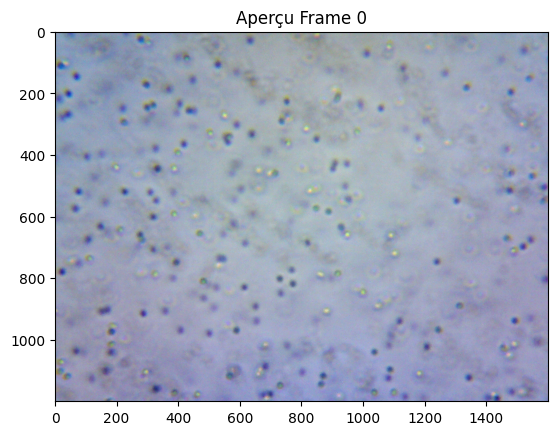

In [ ]:
importlib.reload(video_utils)

# while True:
video_path = video_utils.selectionner_video(DATA)
frame = video_utils.extract_frame(video_path, 0)

# On convertit BGR (OpenCV) en RGB (Matplotlib) pour les vraies couleurs
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Affichage non-bloquant avec Matplotlib
plt.imshow(frame_rgb)
plt.title("Aperçu Frame 0")
plt.show(block=False) # <--- TRÈS IMPORTANT : ne bloque pas la console
plt.pause(0.1)        # Laisse le temps à l'image de s'afficher

# Confirmation (Correction : on teste bien 'conf')
# conf = input("Est-ce la bonne vidéo ? (o/n) : ").lower()
# conf = input("Validation (o/n) > ").strip().lower()
# conf = str(input("Confirmes-tu ce choix ? (o/n) > "))

# if conf == "o":
#     print("Vidéo validée.")
#     plt.close() # Ferme l'image
#     break
# else:
#     plt.close()
#     print("Recommençons la sélection...")

# Calcul du fond moyen et test de filtrage gaussien

In [ ]:
!ls /content/drive/MyDrive/Colab_Notebooks/Brownian_motion_project/src


ls: cannot access '/content/drive/MyDrive/Colab_Notebooks/Brownian_motion_project/src': No such file or directory


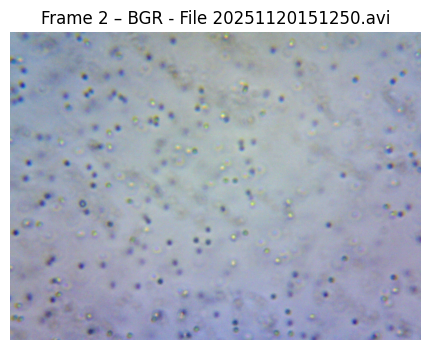

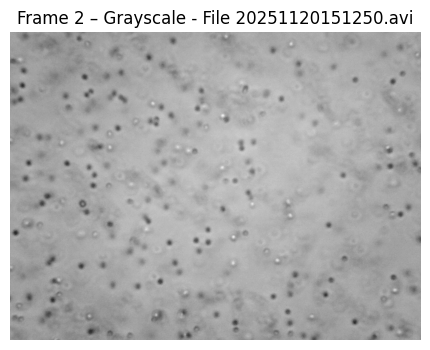

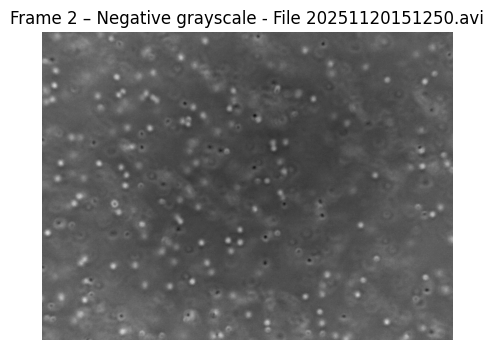

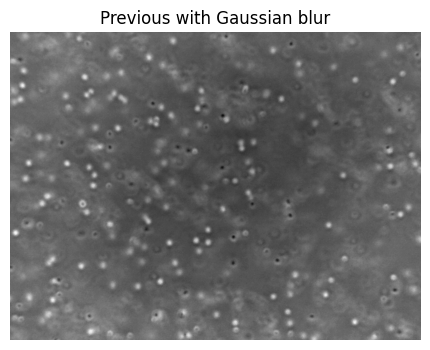

In [ ]:
# ----------------------------
# Vidéo: ouverture & infos & chargement d'une frame test
# Par défaut la première frame est chargée (index = 0) sinon changer
# la valeur d'index
# ----------------------------
import importlib
import video_utils
importlib.reload(video_utils)

index=2

filename = os.path.basename(video_path)

frame = video_utils.extract_frame(video_path, index)
video_utils.show_bgr(frame, f"Frame {index} – BGR - File {filename}")

gray = video_utils.to_grayscale(frame)
video_utils.show_gray(gray, f"Frame {index} – Grayscale - File {filename}")

invert_gray = 255 - gray
video_utils.show_gray(invert_gray, f"Frame {index} – Negative grayscale - File {filename}")

img_clean = cv2.GaussianBlur(invert_gray, (3,3), 0)
video_utils.show_gray(img_clean, "Previous with Gaussian blur")

# Lecture de toute la vidéo et calcul du fond moyen
bg = video_utils.compute_median_background(video_path) - 128
video_utils.show_gray(bg, f"Mean grayscale background - File {filename}")

corr = gray - bg + 128
video_utils.show_gray(corr, f"Frame {index} - Background corrected - File {filename}")

img_clean = cv2.GaussianBlur(corr, (3,3), 0)
video_utils.show_gray(img_clean, "Previous with Gaussian blur")

# Tuning des paramètres d'identification des globules


(102, 8)


<Figure size 1200x1000 with 0 Axes>

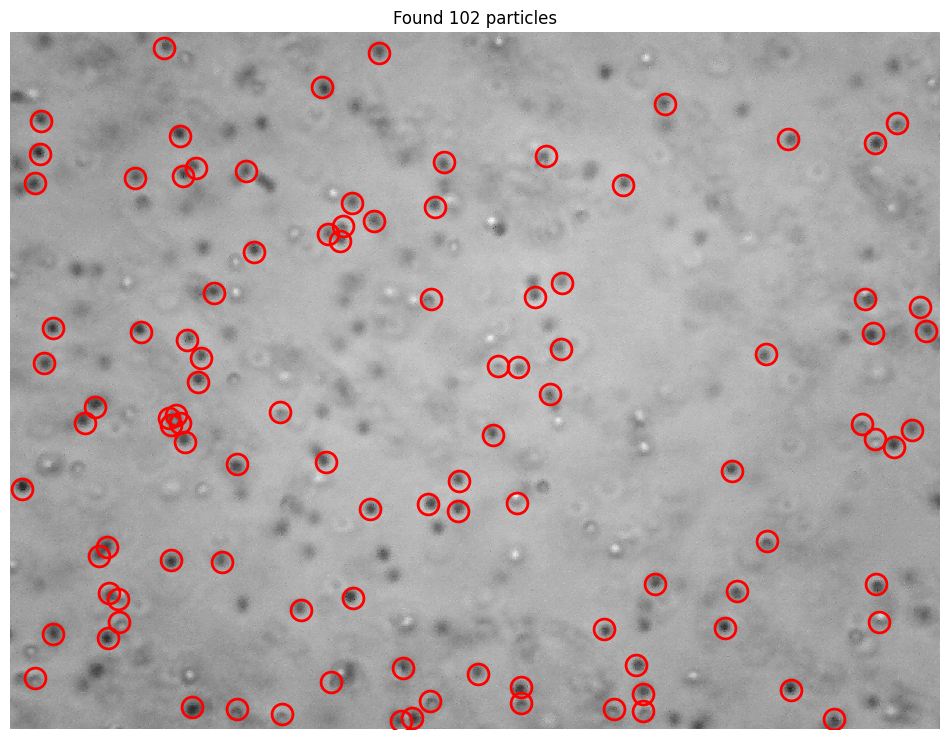

(75, 8)


<Figure size 1200x1000 with 0 Axes>

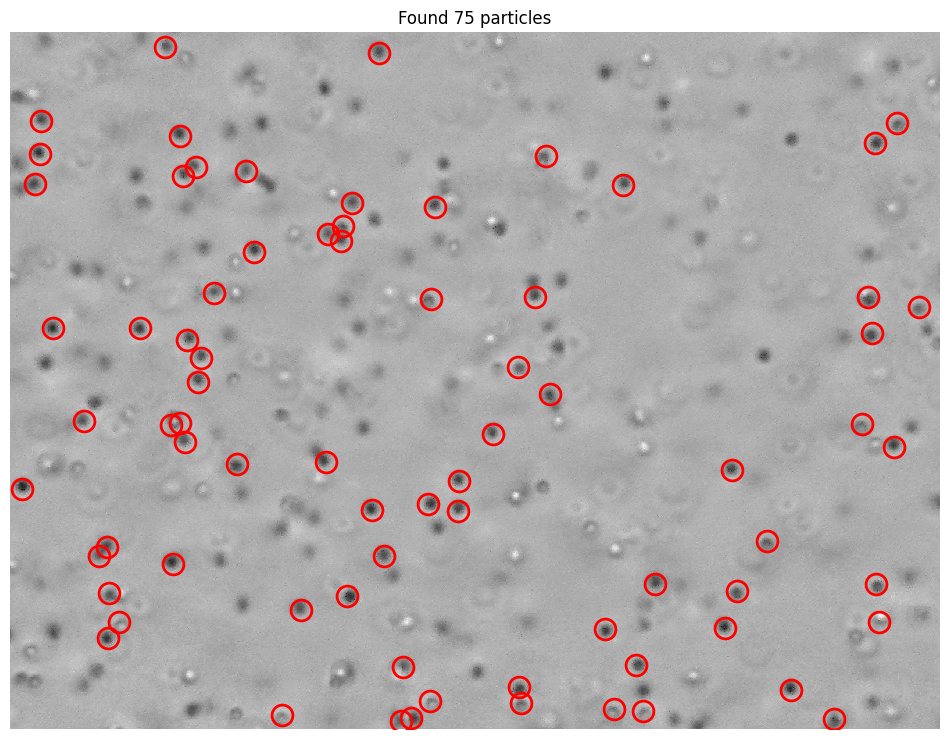

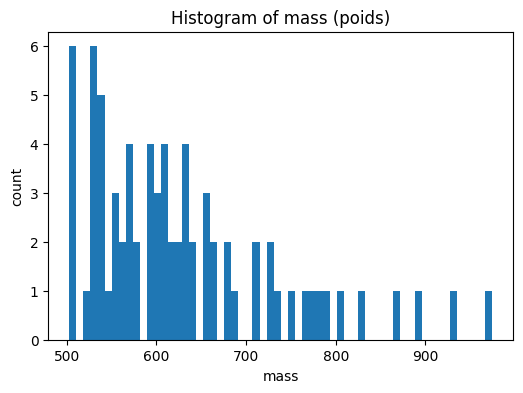

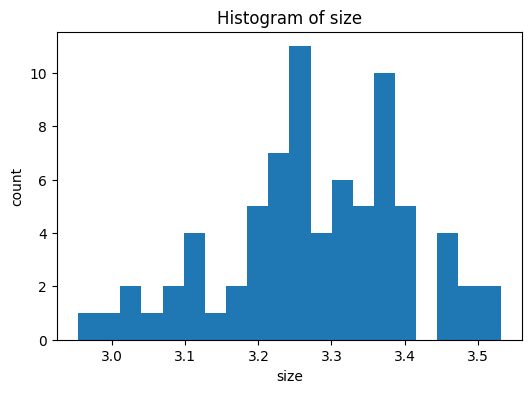

In [ ]:
import matplotlib.pyplot as plt
import trackpy as tp

# Détection (sur image inversée)
diameter = 11      # à ajuster (doit être impair)
minmass  = 500     # à ajuster (filtre contraste/bruit)
features = tp.locate(invert_gray, diameter=diameter, minmass=minmass)
print(features.shape)
features.head()


plt.figure(figsize=(12, 10))
fig, ax = plt.subplots(figsize=(12, 10))

tp.annotate(features, gray, ax=ax)
ax.set_title(f"Found {len(features)} particles")
ax.axis("off")
plt.show()


# Détection (sur image inversée)
features = tp.locate(255-corr, diameter=diameter, minmass=minmass)
print(features.shape)
features.head()


plt.figure(figsize=(12, 10))
fig, ax = plt.subplots(figsize=(12, 10))

tp.annotate(features, corr, ax=ax)
ax.set_title(f"Found {len(features)} particles")
ax.axis("off")
plt.show()

#Vérifie les paramètres
plt.figure(figsize=(6,4))
plt.hist(features["mass"], bins=60)
plt.title("Histogram of mass (poids)")
plt.xlabel("mass")
plt.ylabel("count")
plt.show()

if "size" in features.columns:
    plt.figure(figsize=(6,4))
    plt.hist(features["size"], bins=20)
    plt.title("Histogram of size")
    plt.xlabel("size")
    plt.ylabel("count")
    plt.show()

In [ ]:
size_moyen = features['size'].median()
size_moyen

3.1057282471596706

# Calcul du facteur d'échelle (px/μm)
### 1. Sélection de la video ou de l'image
### 2. Extraction automatique des distances entre graduations
### 3. Élimination des valeurs aberrantes
### 4. Calcul du facteur d'échelle computed_scale en px/μm


--- Menu des vidéos disponibles dans '/content/drive/MyDrive/Michelet_TIPE_CUBE/Brownian_motion_project/data' ---
[0] 20251120151250.avi
[1] 20251113162331.avi
[2] 20251113161332.avi
[3] 20251120153700.avi
[4] 20251120154834.avi
[5] 20251120155101 - Trim.avi
[6] 20251120151656.avi
[7] 20251120150025.avi
[8] IMG_0825.JPG
[9] 20260122163803.avi

Sélectionnez le numéro de la vidéo (0-9) : 3
Fichier sélectionné : 20251120153700.avi


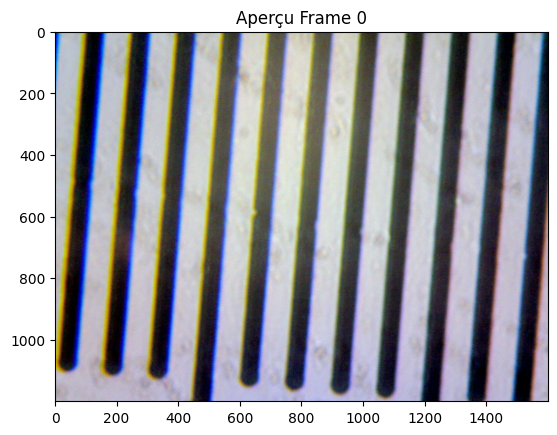

Dimensions des frames de la video 1200x1600
Dimensions des frames étalonnage 1200x1600


In [ ]:




importlib.reload(scale_utils)

# Sélection de la vidéo étalon
path_etalon = video_utils.selectionner_video(DATA)
frame = video_utils.extract_frame(path_etalon, 0)
# On convertit BGR (OpenCV) en RGB (Matplotlib) pour les vraies couleurs
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Affichage non-bloquant avec Matplotlib
plt.imshow(frame_rgb)
plt.title("Aperçu Frame 0")
plt.show(block=False) # <--- TRÈS IMPORTANT : ne bloque pas la console
plt.pause(0.1)        # Laisse le temps à l'image de s'afficher



# Affiche les dimensions de la video sélectionnée
# et de la vidéo d'étalonnage qui doivent être identiques

info=video_utils.video_info(video_path)
print(f"Dimensions des frames de la video {info["height"]}x{info["width"]}")
infob=video_utils.video_info(path_etalon)
print(f"Dimensions des frames étalonnage {infob["height"]}x{info["width"]}")

Angle dominant graduations (deg): -85.23635830927383
Nb graduations détectées: 12
Distances (px): [121.3603932  147.79907684 147.68417442 147.81925015 148.03742622
 148.02757249 148.1181696  147.98090508 147.82175996 148.1000123
 144.85811509]
Moyenne: 145.23698685132373 Std: 7.602598127946461
Moyenne finale : 147.932 px
Écart-type final : 0.15 px
Valeurs gardées : 9 sur 11
Valeurs exclues : [121.3603932  144.85811509]
Measured scale factor: 14.79 ± 0.15 px/µm


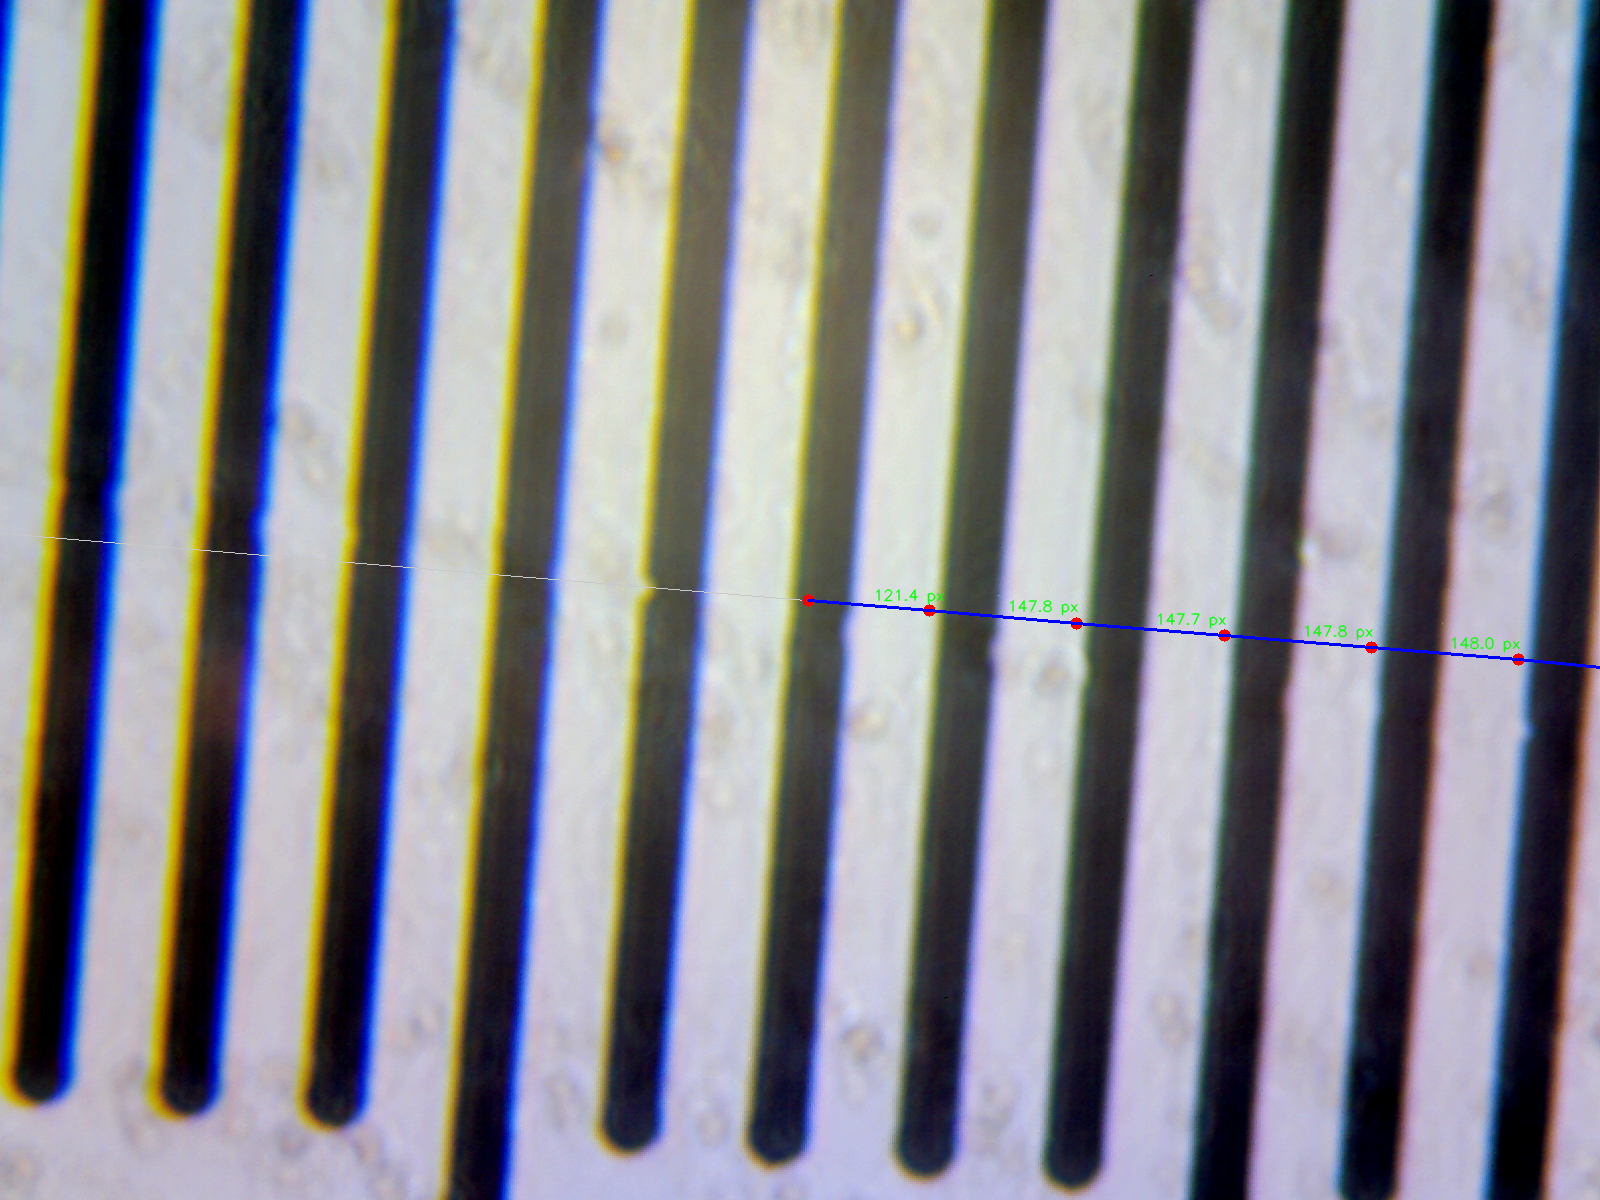

In [ ]:
# Calcul des distances inter-graduations
from google.colab.patches import cv2_imshow

# Chargement d'une image de la video etalon
frame = scale_utils.median_background(path_etalon, 30)
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

import cv2


# ---- 2) Angle ----
angle, bin_inv = scale_utils.estimate_angle_hough(gray)
if angle is None:
    raise RuntimeError("Angle non trouvé. Conseil: recadrer (ROI) autour de l'étalon.")
print("Angle dominant graduations (deg):", angle)

# ---- 3) Positions + distances ----
ticks, dist_px, clean = scale_utils.compute_tick_positions(gray, angle, bin_inv)
print("Nb graduations détectées:", len(ticks))
print("Distances (px):", dist_px)
if len(dist_px) > 0:
    print("Moyenne:", dist_px.mean(), "Std:", dist_px.std())
    # 1. Calcul de la médiane
    mediane = np.median(dist_px)
    # 2. Calcul de la MAD (Ecart Médian Absolu)
    # C'est la mesure de dispersion robuste
    mad = np.median(np.abs(dist_px - mediane))
    # 3. Calcul du Z-score modifié
    # Le facteur 0.6745 sert à rendre le score comparable au Z-score classique
    modified_z_scores = 0.6745 * (dist_px - mediane) / mad
    # 4. Filtrage strict (seuil de 3.5 est le standard, mais ici 2.0 suffit)
    seuil_robuste = 2.0
    dist_px_clean = dist_px[np.abs(modified_z_scores) < seuil_robuste]
    print(f"Moyenne finale : {np.mean(dist_px_clean):.3f} px")
    print(f"Écart-type final : {np.std(dist_px_clean):.2f} px")
    print(f"Valeurs gardées : {len(dist_px_clean)} sur {len(dist_px)}")
    print(f"Valeurs exclues : {dist_px[np.abs(modified_z_scores) >= seuil_robuste]}")
    measured_scale_factor=dist_px_clean.mean()/10

# Tout doit être à l'intérieur des guillemets après le 'f'
print(f"Measured scale factor: {measured_scale_factor:.2f} ± {dist_px_clean.std():.2f} px/µm")
annotated = scale_utils.draw_distances(frame, ticks, angle)

cv2_imshow(annotated)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Traitement de toute la video

In [ ]:
# first install trackpy with: !pip install trackpy opencv-python imageio
# import numpy as np
# import pandas as pd
# import trackpy as tp
# import matplotlib.pyplot as plt
# import imageio.v3 as iio
# from scipy.stats import linregress

# --- 1. CONFIGURATION PARAMÈTRES ---
# Paramètres à ajuster
print(f"\n--- CONFIGURATION POUR : {os.path.basename(video_path)} ---")
MEMORY=1
MIN_STEPS=5
DIAMETER = 11      # diamètre IMPAIR
MIN_MASS = 500     # Minimum de luminosité
SEARCH_RANGE = 20   # distance max de déplacement d'un pixel
MEMORY = 1         # on autorise le programme à perdre de vu un grain pendant 1 image
SCALE = 10        # si le facteur d'échelle est trop incohérent prendre la valeur 10
if measured_scale_factor == 0:
    measured_scale_factor = SCALE

# 1. Validation du Diamètre
user_diam = input(f"Diamètre [{DIAMETER} px] : ")

# Si l'utilisateur fait juste Entrée (chaîne vide), on garde la valeur suggérée
diam_final = int(user_diam) if user_diam.strip() else DIAMETER

# 2. Validation de la Masse (Minmass)
user_mass = input(f"MinMass [{MIN_MASS}] : ")
mass_final = int(user_mass) if user_mass.strip() else MIN_MASS

# 3. Validation de l'échelle (res_pixel)
user_scale = input(f"[{measured_scale_factor:.2f} px/µm] : ")
scale_final = float(user_scale) if user_scale.strip() else measured_scale_factor # 2. Validation de la Masse (Minmass)

# 4. Validation du Search Range
user_range = input(f"Search Range [{SEARCH_RANGE} px] : ")
range_final = int(user_range) if user_range.strip() else SEARCH_RANGE

print(f"-> Paramètres retenus : Diamètre = {diam_final}, MinMass = {mass_final}, Scale = {scale_final}, Search range = {range_final}")


# --- 2. LOCALISATION DES BILLES ---

def load_images_and_detect(video_path,indices, diameter, minmass):

    images = []
    for i, frame_bgr in video_utils.iter_frames(video_path, indices=indices):
        gray = video_utils.to_grayscale(frame_bgr)
        inv  = 255 - (gray - bg)
        images.append(inv)

    features = tp.batch(images, diameter=diameter, minmass=minmass, processes=1)
    features["frame"] = [indices[i] for i in features["frame"]]  # remap vers indices réels
    display(features.head())
    print("Nb particules détectées:", len(features))

    info = video_utils.video_info(video_path)
    for k, v in info.items():
      print(f"{k:>10}: {v}")

    return features

# --- 3. LIER LES COORDONNÉES ---

def link_trajectories(features, search_range, memory,min_steps):
    print("\n--- Linking Trajectories ---")

        # Lie les trajectoires
    linked = tp.link_df(
        features,
        search_range=search_range,
        memory=memory)

    # Filtre les trop petites trajectoires
    t = tp.filter_stubs(linked, min_steps)
    t["ID"] = t["particle"]    # alias
    num_particles = t['particle'].nunique()
    print(f"Total linked trajectories (>= {min_steps} steps): {num_particles}")

    return t

# --- 4. CALCUL DU MSD ---

def plot_trajectories(linked_df, scale):
    print("\n--- Plotting Trajectories ---")

    df = linked_df.copy()

    # conversion pixel --> unité
    df[['x', 'y']] = df[['x', 'y']] / scale

    # Translate à l'origine
    # Soustrait la première position de chaque tajectoire
    x0 = df.groupby('ID')['x'].transform('first')
    y0 = df.groupby('ID')['y'].transform('first')

    df['x_rel'] = df['x'] - x0
    df['y_rel'] = df['y'] - y0

    # Tracé
    plt.figure(figsize=(7, 7))
    for particle_id in df['ID'].unique():
        p_data = df[df['ID'] == particle_id]
        plt.plot(p_data['x_rel'], p_data['y_rel'], alpha=0.5,
                 linewidth=0.5)

    plt.xlabel("Déplacement X ($\mu$m)")
    plt.ylabel("Déplacement Y ($\mu$m)")
    plt.title("Trajectoires des billes (Translatées à l'origine)")
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True)
    plt.show()


    # Calcule le MSD de chaque particule

def calculate_and_plot_msd(linked_df, fps, scale):
    print("\n--- Calculating and Plotting MSD ---")
    dt = 1 / fps
    print(dt)


    # Calcule le MSD de l'ensemble
    msd_ens = tp.emsd(trajectories, mpp=1.0, fps=fps)  # mpp=1 => unités en pixels
    display(msd_ens.head())
    msd_each = tp.imsd(trajectories,mpp=1.0,fps=fps)

    # Trace les MSDs individuels
    plt.figure(figsize=(7,5))
    for col in msd_each.columns[:]:
      plt.plot(msd_each.index, msd_each[col], alpha=0.7)
    plt.xlabel("lag time (s)")
    plt.ylabel("MSD (px²)")
    plt.title("Individual MSDs (first 5 particles)")
    plt.show()

    # Trace MSD de l'ensemble

    # 1. Tracé des points expérimentaux
    plt.figure(figsize=(7, 5))
    plt.plot(msd_ens.index, msd_ens.values, "o", label="MSD expérimental", markersize=5)

    # 2. Calcul de la régression
    t = msd_ens.index.values
    y = msd_ens.values
    k = 20  # On se concentre sur les premiers points où le modèle est le plus fiable
    a, b = np.polyfit(t[:k], y[:k], 1)

    # 3. Création de la ligne de régression pour le graphique
    # On trace la droite sur toute la plage de temps pour voir la divergence éventuelle
    t_fit = np.linspace(0, t.max(), 100)
    y_fit = a * t_fit + b

    plt.plot(t_fit, y_fit, "r--", label=f"Régression (k={k} pts)")

    # 4. Habillage du graphique
    plt.xlabel("Lag time $\Delta t$ (s)")
    plt.ylabel("MSD (px²)")
    plt.title("Ensemble Mean Squared Displacement")

    # Ajout d'une boîte de texte avec les résultats physiques
    textstr = '\n'.join((
        r'$a = %.3f$ px²/s' % (a, ),
        r'$D \approx %.3f$ px²/s' % (a/4, )))

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
            verticalalignment='top', bbox=props)

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    D = a / 4.0
    print(f"Pente (a) = {a:.3f} px²/s")
    print(f"Coefficient D = {D:.3f} px²/s")


    # --- Tracé ---
    plt.figure(figsize=(7,5))

    # Log-log plot pour verifier la loi linéaire
    time_lags = msd_ens.index
    msd_values = msd_ens.values

    plt.loglog(time_lags, msd_values, 'o', alpha=0.6, label='MSD Data')
    plt.xlabel('Time Lag $\\tau$ (s)')
    plt.ylabel('MSD ($\mu$m$^2$)')
    plt.title('Ensemble Mean Squared Displacement (Log-Log)')

    # --- Extraction du coeff de diffusion ---

    # 1. Faire correspondre le modèle à la partie linéaire de la courbe

    # on exclut les temps trop courts
    fit_start_index = 1
    fit_end_index = 20

    log_time = np.log(time_lags[fit_start_index:fit_end_index])
    log_msd = np.log(msd_values[fit_start_index:fit_end_index])

    slope_log, intercept_log, _, _, _ = linregress(log_time[:6], log_msd[:6])

    # 2. Extraire la pente puis D du modèle(MSD = 4 * D * tau)

    # We use a linear range for this.
    linear_slope, _, _, _, _ = linregress(time_lags[fit_start_index:fit_end_index], msd_values[fit_start_index:fit_end_index])
    Diffusion_Coefficient = linear_slope / 4.0

    # Trace la droite modele log-log
    plt.plot(time_lags, np.exp(intercept_log + slope_log * np.log(time_lags)),
             'r--', label=f'Fit: $\\text{{MSD}} \\propto \\tau^{{{slope_log:.2f}}}$')

    plt.legend()
    plt.grid(True, which="both", ls="-")
    plt.show()

    print("\n--- Diffusion Results ---")
    print(f"Extracted Diffusion Coefficient (D): {Diffusion_Coefficient:.4e} $\\mu$m$^2$/s")
    print(f"Power Law Exponent ($\\alpha$): {slope_log:.2f} (Should be near 1.0 for Fickian diffusion)")

# --- 5. EXÉCUTION ---

if __name__ == "__main__":
    # 1. Load Data and localize particles
    # frames = load_frames(VIDEO_PATH)
    info=video_utils.video_info(video_path)
    fps=int(info["fps"])
    n_frames=int(info["n_frames"])
    indices = list(range(2, min(99,n_frames-1), 1))
    features=load_images_and_detect(video_path,indices,diam_final,mass_final)



    # 2. Lie trajectoires
    trajectories = link_trajectories(features, range_final, MEMORY,MIN_STEPS)

    # 3. Trace trajectoires
    plot_trajectories(trajectories, scale_final)

    # 4. Calcul du MSD
    calculate_and_plot_msd(trajectories, fps, scale_final)


<>:103: SyntaxWarning: invalid escape sequence '\m'
<>:104: SyntaxWarning: invalid escape sequence '\m'
<>:152: SyntaxWarning: invalid escape sequence '\D'
<>:183: SyntaxWarning: invalid escape sequence '\m'
<>:103: SyntaxWarning: invalid escape sequence '\m'
<>:104: SyntaxWarning: invalid escape sequence '\m'
<>:152: SyntaxWarning: invalid escape sequence '\D'
<>:183: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_12095/271428694.py:103: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Déplacement X ($\mu$m)")
/tmp/ipykernel_12095/271428694.py:104: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Déplacement Y ($\mu$m)")
/tmp/ipykernel_12095/271428694.py:152: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("Lag time $\Delta t$ (s)")
/tmp/ipykernel_12095/271428694.py:183: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('MSD ($\mu$m$^2$)')


NameError: name 'os' is not defined

In [ ]:
video_path, n_frames

('/content/drive/MyDrive/Colab_Notebooks/Brownian_motion_project/data/20251120151250.avi',
 100)

# Création d'un video de debuggage

In [ ]:
#Creation of a debug video
import os
import cv2

from IPython.display import Video, display

def make_tp_batch_debug_video(
    video_path,
    indices,
    diameter,
    minmass,
    out_mp4_path,
    preprocess_fn=None,   # prend gray(uint8) -> img_for_tp(uint8) (optionnel)
    draw_radius=None,     # si None, radius = diameter//2
    fps_out=None,
    show_text=True
):
    """
    - Charge uniquement les frames 'indices' (via video_utils.iter_frames)
    - Prétraite (optionnel), inverse si ton preprocess le fait ou non (à toi)
    - Fait tp.batch sur la liste d'images
    - Dessine les détections sur la frame grayscale (en rouge)
    - Sauve en mp4
    """
    import trackpy as tp
    import video_utils  # ton module

    # 1) Lire les frames + construire les images pour tp.batch
    frames_gray = []
    images_tp = []
    indices = list(indices)

    for j, (i, frame_bgr) in enumerate(video_utils.iter_frames(video_path, indices=indices)):
        gray = video_utils.to_grayscale(frame_bgr)  # uint8 (H,W)
        frames_gray.append(gray)

        img = gray
        if preprocess_fn is not None:
            img = preprocess_fn(gray)

        # Si tu veux forcer particules noires -> claires ici :
        # img = 255 - img

        images_tp.append(img)

    if len(images_tp) == 0:
        raise ValueError("No frames loaded. Check indices/video_path.")

    H, W = frames_gray[0].shape[:2]

    # 2) Détection batch
    features = tp.batch(images_tp, diameter=diameter, minmass=minmass, processes=1)

    # 3) Préparer writer vidéo
    if fps_out is None:
        # fps de sortie: soit celui de la vidéo si dispo, sinon 10
        try:
            info = get_videoinfo(video_path)
            fps_out = info["fps"] if info["fps"] else 10
        except Exception:
            fps_out = 10

    os.makedirs(os.path.dirname(out_mp4_path), exist_ok=True)
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(out_mp4_path, fourcc, float(fps_out), (W, H))

    r = (diameter // 2) if draw_radius is None else int(draw_radius)

    # 4) Dessiner frame par frame
    # Note: features['frame'] ici est 0..len(indices)-1 (car images_tp est une liste)
    for fidx in range(len(indices)):
        gray = frames_gray[fidx]
        canvas = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

        sub = features[features["frame"] == fidx]

        # cercles rouges autour des détections
        for _, row in sub.iterrows():
            x, y = int(round(row["x"])), int(round(row["y"]))
            cv2.circle(canvas, (x, y), r, (0, 0, 255), 2)

        if show_text:
            txt = f"frame_list_idx={fidx}  orig_frame={indices[fidx]}  n={len(sub)}"
            cv2.putText(canvas, txt, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,255), 2)

        writer.write(canvas)

    writer.release()
    return features


In [ ]:
indices = list(range(20))

def preprocess(gray):
    inv = 255 - gray
    # optionnel: petit flou
    inv = cv2.GaussianBlur(inv, (3,3), 0)
    return inv

out_path = f"{OUT}/debug_tp_batch.mp4"

features = make_tp_batch_debug_video(
    video_path=video_path,
    indices=indices,
    diameter=diameter,
    minmass=minmass,
    out_mp4_path=out_path,
    preprocess_fn=preprocess,
    fps_out=10
)

print(features.shape, "frames uniques:", features["frame"].nunique())
display(Video(out_path, embed=True))


In [ ]:
import numpy as np

def filtrer_par_msd_moyen(trajectoires, seuil_msd=5.0):
    trajectoires_mobiles = {}
    msd_moyens = []

    for id_particule, positions in trajectoires.items():
        # Conversion en tableau 1D
        data = np.array(positions)

        # Sécurité : Si le nombre d'éléments est impair, on retire le dernier
        if data.size % 2 != 0:
            data = data[:-1]

        # Maintenant on peut transformer en (N, 2) sans erreur
        pos = data.reshape(-1, 2)

        # Calcul du MSD
        p_initial = pos[0]
        deplacements_carre = np.sum((pos - p_initial)**2, axis=1)

        msd_moyen_particule = np.mean(deplacements_carre)
        msd_moyens.append(msd_moyen_particule)

        # Filtrage
        if msd_moyen_particule > seuil_msd:
            trajectoires_mobiles[id_particule] = positions

    return trajectoires_mobiles, msd_moyens

# Utilisation :
# traj_propres, tous_les_msd = filtrer_par_msd_moyen(trajectoires, seuil_msd=5.0)

In [ ]:
msd_ens.values()

TypeError: 'numpy.ndarray' object is not callable

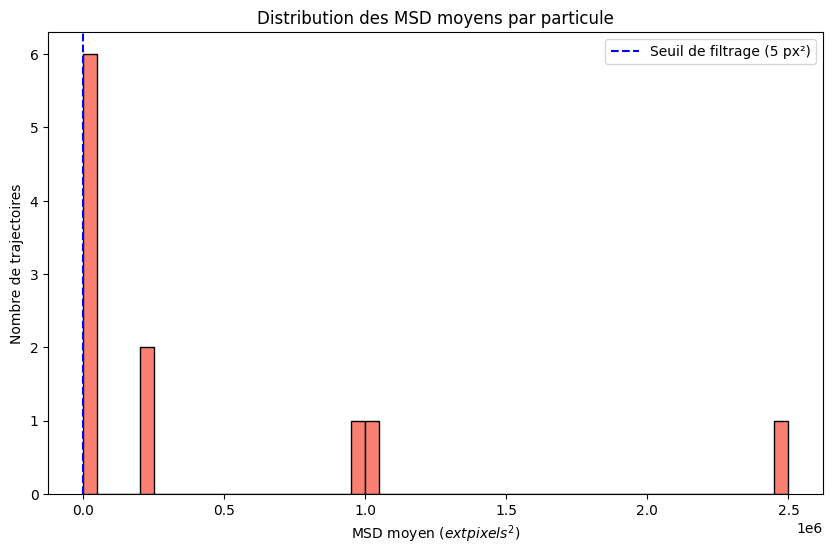

[np.float64(1004212.6869942585), np.float64(984954.3963158971), np.float64(27225.95044120575), np.float64(0.03415841225726779), np.float64(0.012600873241545163)]
Nombre de particules au départ : 4437
Nombre de particules après filtrage : 8


In [ ]:
traj_propres, tous_les_msd = filtrer_par_msd_moyen(trajectories, seuil_msd=10.0)
plt.figure(figsize=(10, 6))
plt.hist(tous_les_msd, bins=50, color='salmon', edgecolor='black')
plt.axvline(x=5, color='blue', linestyle='--', label='Seuil de filtrage (5 px²)')
plt.title("Distribution des MSD moyens par particule")
plt.xlabel("MSD moyen ($\text{pixels}^2$)")
plt.ylabel("Nombre de trajectoires")
plt.legend()
plt.show()
print(tous_les_msd[:5])
print(f"Nombre de particules au départ : {len(trajectories)}")
print(f"Nombre de particules après filtrage : {len(traj_propres)}")

In [ ]:
import numpy as np
import pandas as pd

def filtrer_msd_final(df, seuil_msd=20):
    # 1. On règle le conflit 'frame' : on réinitialise l'index
    # et on supprime les niveaux d'index qui s'appelleraient déjà comme nos colonnes
    df_clean = df.copy()
    if df_clean.index.name is not None:
        df_clean = df_clean.reset_index(drop=True)

    # 2. Tri chronologique pour chaque particule
    df_clean = df_clean.sort_values(by=['particle', 'frame'])

    # 3. Calcul du MSD par groupe (plus rapide et robuste)
    def calcul_msd(groupe):
        x = groupe['x'].values
        y = groupe['y'].values
        # (x - x_initial)^2 + (y - y_initial)^2
        return np.mean((x - x[0])**2 + (y - y[0])**2)

    # On calcule le MSD pour chaque particule
    stats_msd = df_clean.groupby('particle').apply(calcul_msd)

    # 4. On ne garde que les IDs dont le MSD moyen > seuil
    ids_valides = stats_msd[stats_msd > seuil_msd].index

    return df_clean[df_clean['particle'].isin(ids_valides)].copy()

# --- EXÉCUTION ---
# On filtre les trajectoires
df_filtre = filtrer_msd_final(trajectories, seuil_msd=5.0)

# On affiche le graphique
plot_trajectories(df_filtre, SCALE)
# Calcul du nombre de trajectoires (particules uniques)
nb_initial = trajectories['particle'].nunique()
nb_final = df_filtre['particle'].nunique()
nb_retirees = nb_initial - nb_final
pourcentage = (nb_retirees / nb_initial) * 100

print(f"--- BILAN DU FILTRAGE ---")
print(f"Trajectoires au départ     : {nb_initial}")
print(f"Trajectoires conservées    : {nb_final}")
print(f"Trajectoires retirées      : {nb_retirees} ({pourcentage:.1f}%)")

In [ ]:
import matplotlib.pyplot as plt

# 1. On calcule le MSD moyen pour CHAQUE particule sans filtrer
def obtenir_tous_les_msd(df):
    df_tri = df.reset_index(drop=True).sort_values(by=['particle', 'frame'])
    msds = []
    for p_id in df_tri['particle'].unique():
        data = df_tri[df_tri['particle'] == p_id]
        x, y = data['x'].values, data['y'].values
        val = np.mean((x - x[0])**2 + (y - y[0])**2)
        msds.append(val)
    return np.array(msds)

tous_msd = obtenir_tous_les_msd(trajectories)

# 2. On trace l'histogramme
plt.figure(figsize=(10, 6))
plt.hist(tous_msd, bins=50, color='skyblue', edgecolor='black')
plt.yscale('log') # On met l'échelle en Log pour voir les petits groupes
plt.title("Distribution des MSD moyens des particules")
plt.xlabel("Valeur du MSD (px²)")
plt.ylabel("Nombre de particules (Log)")
plt.grid(True, alpha=0.3)
plt.show()

# 3. On affiche les statistiques pour comprendre
print(f"MSD Minimum : {tous_msd.min():.2f}")
print(f"MSD Maximum : {tous_msd.max():.2f}")
print(f"MSD Médian  : {np.median(tous_msd):.2f}")

In [ ]:
import pandas as pd
import numpy as np

# 1. On s'assure que 'particle' est bien un entier
trajectories['particle'] = trajectories['particle'].astype(int)

# 2. Calcul des MSD manuellement
ids_mobiles = []
for p_id in trajectories['particle'].unique():
    subset = trajectories[trajectories['particle'] == p_id]
    # On prend le premier et le dernier point pour simplifier au maximum
    x = subset['x'].values
    y = subset['y'].values
    msd = (x[-1] - x[0])**2 + (y[-1] - y[0])**2

    if msd > 5: # Seuil agressif pour tester
        ids_mobiles.append(p_id)

# 3. Application du filtre
df_test = trajectories[trajectories['particle'].isin(ids_mobiles)].copy()

# 4. VERIFICATION IMMEDIATE
print(f"ID uniques avant : {trajectories['particle'].nunique()}")
print(f"ID uniques après : {df_test['particle'].nunique()}")
print(f"Les 5 premiers ID conservés : {ids_mobiles[:5]}")

# Diagnostics

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def tracer_histogramme_deplacement(trajectoires):
    distances = []

    for id_particule, positions in trajectoires.items():
        p_init = positions[0]
        p_final = positions[-1]
        # Calcul de la distance euclidienne totale
        dist = ((p_final[0] - p_init[0])**2 + (p_final[1] - p_init[1])**2)**0.5
        distances.append(dist)

    plt.figure(figsize=(10, 6))
    plt.hist(distances, bins=50, color='skyblue', edgecolor='black')
    plt.axvline(x=5, color='red', linestyle='--', label='Seuil suggéré (5 px)') # Exemple de seuil
    plt.title("Répartition des déplacements totaux des particules")
    plt.xlabel("Distance totale parcourue (pixels)")
    plt.ylabel("Nombre de particules")
    plt.legend()
    plt.show()

# Utilisation :
#
tracer_histogramme_deplacement(trajectories)

KeyError: 0

In [ ]:
info=video_utils.video_info(video_path)
fps = int(info["fps"])
print(f"La vidéo tourne à {fps} images par seconde.")
print(info["n_frames"])

La vidéo tourne à 7 images par seconde.
100


In [ ]:
ms=5
for SEARCH_RANGE in [9]:
    print("\n==============================")
    print(f"Testing min_steps = {ms}")
    print("==============================")
    t = link_trajectories(features, SEARCH_RANGE, MEMORY, min_steps=ms)

    print(
        f"RESULT → min_steps={ms} | "
        f"n_particles={t['particle'].nunique()} | "
        f"rows={len(t)}"
    )


Frame 98: 58 trajectories present.
Total linked trajectories (>= 5 steps): 323
RESULT → min_steps=5 | n_particles=323 | rows=2363
